In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [28]:
CSV_FILE = "10k_calibration.csv"

In [29]:
df = pd.read_csv(CSV_FILE)

print(df.head())

   frequency    real  imaginary  magnitude  impedance
0     5000.0 -1289.0    19827.0   19868.86   10003.48
1     7000.0 -1811.0    19785.0   19867.71   10004.60
2     9000.0 -2377.0    19745.0   19887.56   10000.68
3    11000.0 -2910.0    19667.0   19881.12   10002.91
4    13000.0 -3466.0    19590.0   19894.25   10003.46


Calculate Phase

In [30]:
df["phase_deg"] = np.degrees(
    np.arctan2(
        df["imaginary"],
        df["real"]
    )
)

df[[
    "frequency",
    "phase_deg"
]].head()

,frequency,phase_deg
0,5000.0,93.719699
1,7000.0,95.229938
2,9000.0,96.864513
3,11000.0,98.416622
4,13000.0,100.033339


Calculate Resistance and Reactance

In [31]:
phase_rad = np.radians(
    df["phase_deg"]
)

df["resistance"] = (
    df["impedance"]
    * np.cos(phase_rad)
)

df["reactance"] = (
    df["impedance"]
    * np.sin(phase_rad)
)

df.head()

,frequency,real,imaginary,magnitude,impedance,phase_deg,resistance,reactance
0,5000.0,-1289.0,19827.0,19868.86,10003.48,93.719699,-648.979767,9982.406392
1,7000.0,-1811.0,19785.0,19867.71,10004.60,95.229938,-911.948562,9962.949914
2,9000.0,-2377.0,19745.0,19887.56,10000.68,96.864513,-1195.300631,9928.990727
3,11000.0,-2910.0,19667.0,19881.12,10002.91,98.416622,-1464.126066,9895.177782
4,13000.0,-3466.0,19590.0,19894.25,10003.46,100.033339,-1742.814590,9850.472541


Impedance Error

In [32]:
REFERENCE_RESISTOR = 10000

In [33]:
df["error_percent"] = (
    (
        df["impedance"]
        - REFERENCE_RESISTOR
    )
    /
    REFERENCE_RESISTOR
    * 100
)

df[[
    "frequency",
    "impedance",
    "error_percent"
]].head()

,frequency,impedance,error_percent
0,5000.0,10003.48,0.0348
1,7000.0,10004.60,0.0460
2,9000.0,10000.68,0.0068
3,11000.0,10002.91,0.0291
4,13000.0,10003.46,0.0346


Plot Impedance

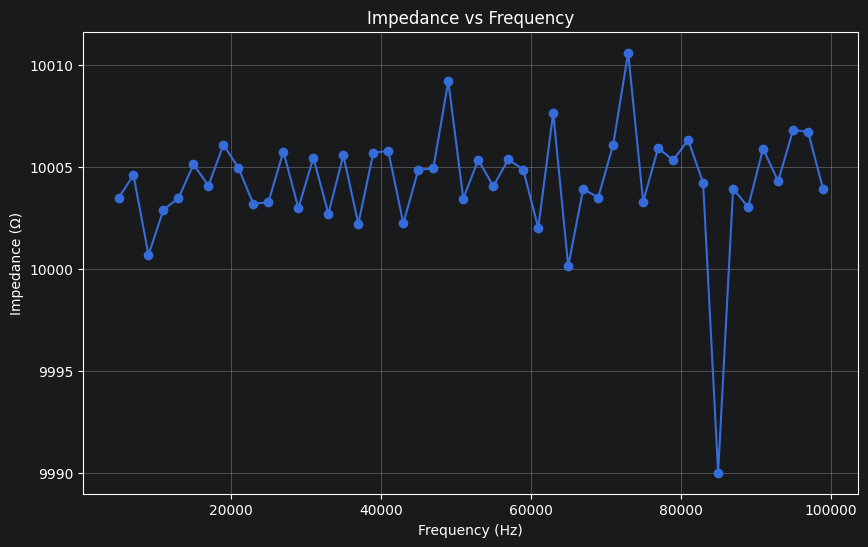

In [34]:
plt.figure(figsize=(10,6))

plt.plot(
    df["frequency"],
    df["impedance"],
    marker="o"
)


plt.title(
    "Impedance vs Frequency"
)

plt.xlabel(
    "Frequency (Hz)"
)

plt.ylabel(
    "Impedance (Ω)"
)

plt.grid(True)

plt.show()

Plot Phase Angle

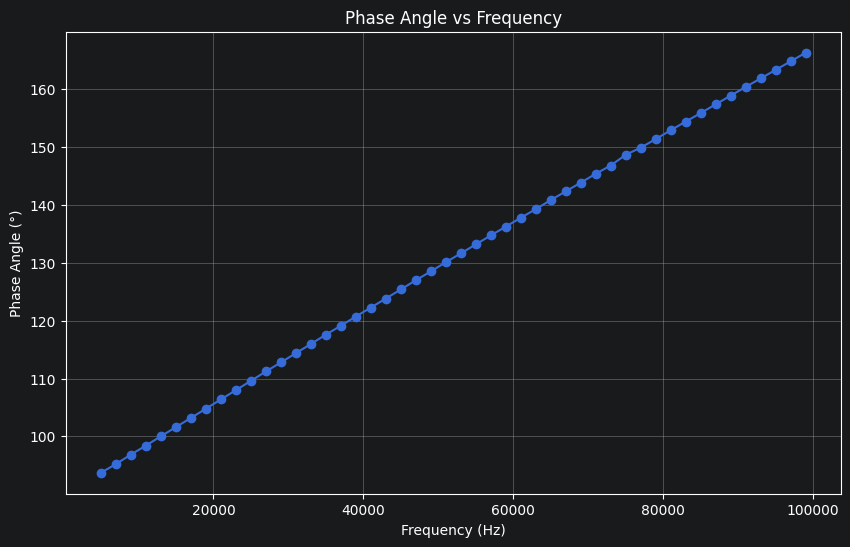

In [35]:
plt.figure(figsize=(10,6))

plt.plot(
    df["frequency"],
    df["phase_deg"],
    marker="o"
)

plt.title(
    "Phase Angle vs Frequency"
)

plt.xlabel(
    "Frequency (Hz)"
)

plt.ylabel(
    "Phase Angle (°)"
)

plt.grid(True)

plt.show()

Nyquist Plot

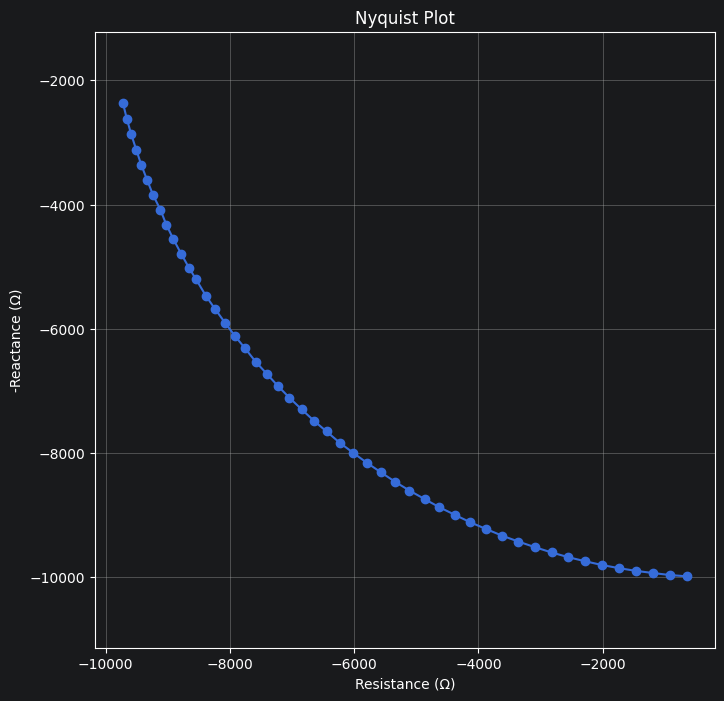

In [36]:
plt.figure(figsize=(8,8))

plt.plot(
    df["resistance"],
    -df["reactance"],
    marker="o"
)

plt.title(
    "Nyquist Plot"
)

plt.xlabel(
    "Resistance (Ω)"
)

plt.ylabel(
    "-Reactance (Ω)"
)

plt.grid(True)

plt.axis("equal")

plt.show()

Summary Statistics

In [37]:
print()

print("========== SUMMARY ==========")

print()

print(
    f"Mean Impedance: "
    f"{df['impedance'].mean():.2f} Ω"
)

print(
    f"Mean Error: "
    f"{df['error_percent'].mean():.2f}%"
)

print(
    f"Max Error: "
    f"{df['error_percent'].max():.2f}%"
)

print(
    f"Min Error: "
    f"{df['error_percent'].min():.2f}%"
)

print(
    f"Mean Phase: "
    f"{df['phase_deg'].mean():.2f}°"
)

print(
    f"Max Phase: "
    f"{df['phase_deg'].max():.2f}°"
)

print(
    f"Min Phase: "
    f"{df['phase_deg'].min():.2f}°"
)


========== SUMMARY ==========

Mean Impedance: 10004.29 Ω
Mean Error: 0.04%
Max Error: 0.11%
Min Error: -0.10%
Mean Phase: 130.52°
Max Phase: 166.31°
Min Phase: 93.72°


Phase Correction Estimate

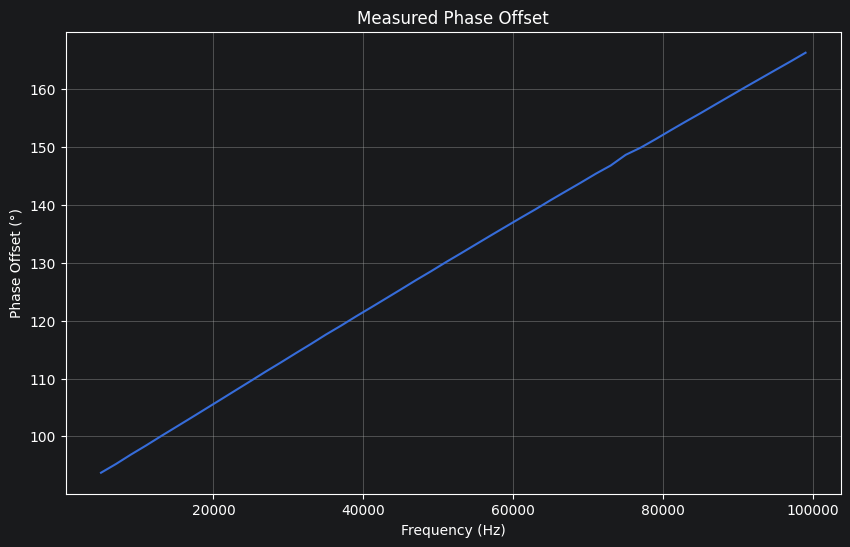

In [38]:
phase_offset = df["phase_deg"]

plt.figure(figsize=(10,6))

plt.plot(
    df["frequency"],
    phase_offset
)

plt.title(
    "Measured Phase Offset"
)

plt.xlabel(
    "Frequency (Hz)"
)

plt.ylabel(
    "Phase Offset (°)"
)

plt.grid(True)

plt.show()

In [39]:
cal = pd.read_csv(
    "10k_calibration.csv"
)

cal["phase_correction"] = np.degrees(
    np.arctan2(
        cal["imaginary"],
        cal["real"]
    )
)

cal[[
    "frequency",
    "phase_correction"
]].to_csv(
    "phase_correction.csv",
    index=False
)

In [40]:
print(df["phase_deg"].min())
print(df["phase_deg"].max())

93.71969899136703
166.30683247769633
